In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split, KFold, cross_val_score, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from scipy import stats

# ==========================================
# LAB 3 - PRZYGOTOWANIE DANYCH I MODEL BAZOWY
# ==========================================

1. Pobranie cen mieszkań z OpenML

In [16]:
# https://www.openml.org/search?type=data&sort=runs&id=42165
# https://www.kaggle.com/c/house-prices-advanced-regression-techniques/data
housing = fetch_openml(name="house_prices", as_frame=True, version=1)
df = housing.frame

2. Wybór najważniejszych cech

In [17]:
features = ['LotArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'GrLivArea',
            'FullBath', 'GarageArea', 'Neighborhood', 'BldgType', 'HouseStyle', 'SalePrice']
df = df[features].copy()

3. Usunięcie duplikatów

In [18]:
print(f"Początkowy rozmiar zbioru: {df.shape}")
df = df.drop_duplicates()
print(f"Rozmiar po usunięciu duplikatów: {df.shape}")

Początkowy rozmiar zbioru: (1460, 11)
Rozmiar po usunięciu duplikatów: (1460, 11)


4. Uzupełnienie braków

In [19]:
# Zmienne numeryczne - zastępujemy braki medianą
num_cols = df.select_dtypes(include=['int64', 'float64']).columns.drop('SalePrice')
imputer_num = SimpleImputer(strategy='median')
df[num_cols] = imputer_num.fit_transform(df[num_cols])

# Zmienne kategoryczne - zastępujemy braki najczęstszą wartością (modą)
cat_cols = df.select_dtypes(include=['object', 'category']).columns
imputer_cat = SimpleImputer(strategy='most_frequent')
df[cat_cols] = imputer_cat.fit_transform(df[cat_cols])

5. Detekcja wartości odstających (Outliers - reguła IQR)

In [20]:
Q1 = df['LotArea'].quantile(0.25)
Q3 = df['LotArea'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['LotArea'] >= lower_bound) & (df['LotArea'] <= upper_bound)]
print(f"Rozmiar po usunięciu wartości odstających: {df.shape}")


Rozmiar po usunięciu wartości odstających: (1391, 11)


6. Kodowanie zmiennych kategorycznych, podział i skalowanie

In [21]:
df = pd.get_dummies(df, columns=cat_cols, drop_first=True)
X = df.drop('SalePrice', axis=1)
y = df['SalePrice']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=1)

# Skalowanie (StandardScaler)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


7. Trenowanie modelu (Regresja liniowa)

In [22]:
benchmark_model = LinearRegression()
benchmark_model.fit(X_train_scaled, y_train)
y_pred_bench = benchmark_model.predict(X_test_scaled)

/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


8. Miary oceny jakości modelu bazowego

In [23]:
mae_bench = mean_absolute_error(y_test, y_pred_bench)
mse_bench = mean_squared_error(y_test, y_pred_bench)
rmse_bench = np.sqrt(mse_bench)
r2_bench = r2_score(y_test, y_pred_bench)

print(f"MAE:  {mae_bench:.2f} $")
print(f"RMSE: {rmse_bench:.2f} $")
print(f"R2:   {r2_bench:.4f}")

MAE:  21455.46 $
RMSE: 33283.24 $
R2:   0.8336


# ==========================================
# LAB 4 - OPTYMALIZACJA I ANALIZA WYNIKÓW
# ==========================================

1. Walidacja K-fold dla Regresji liniowej

In [24]:
kf = KFold(n_splits=5, shuffle=True, random_state=1)
cv_scores = cross_val_score(benchmark_model, X_train_scaled, y_train, cv=kf, scoring='r2')
print(f"Średni wynik R2 z 5-krotnej walidacji: {cv_scores.mean():.4f}")

Średni wynik R2 z 5-krotnej walidacji: 0.8677


/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mateusz/PyCharmMiscProject/.venv/lib/python3.9/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/mateusz/PyCharmMiscProject/.venv/lib/pyth

2. Optymalizacja hiperparametrów

In [25]:
rf = RandomForestRegressor(random_state=1)

# Siatka hiperparametrów do przeszukania
param_dist_rf = {
    'n_estimators': [50, 100, 200],
    'max_depth': [None, 10, 20],
    'min_samples_split': [2, 5, 10]
}

# Szukamy najlepszego modelu
random_search_rf = RandomizedSearchCV(rf, param_distributions=param_dist_rf, n_iter=10, cv=3, scoring='r2', random_state=42, n_jobs=-1)
random_search_rf.fit(X_train_scaled, y_train)

best_rf = random_search_rf.best_estimator_
print(f"Najlepsze hiperparametry RF: {random_search_rf.best_params_}")

Najlepsze hiperparametry RF: {'n_estimators': 200, 'min_samples_split': 2, 'max_depth': 10}


3. Miary oceny jakości nowego modelu

In [26]:
y_pred_rf = best_rf.predict(X_test_scaled)
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"MAE:  {mae_rf:.2f} $")
print(f"RMSE: {rmse_rf:.2f} $")
print(f"R2:   {r2_rf:.4f}")

MAE:  19676.17 $
RMSE: 31883.03 $
R2:   0.8473


4. Analiza istotności cech

In [27]:
importances = best_rf.feature_importances_
feature_names = X.columns
indices = np.argsort(importances)[::-1]

5. Wykres 10 najważniejszych cech

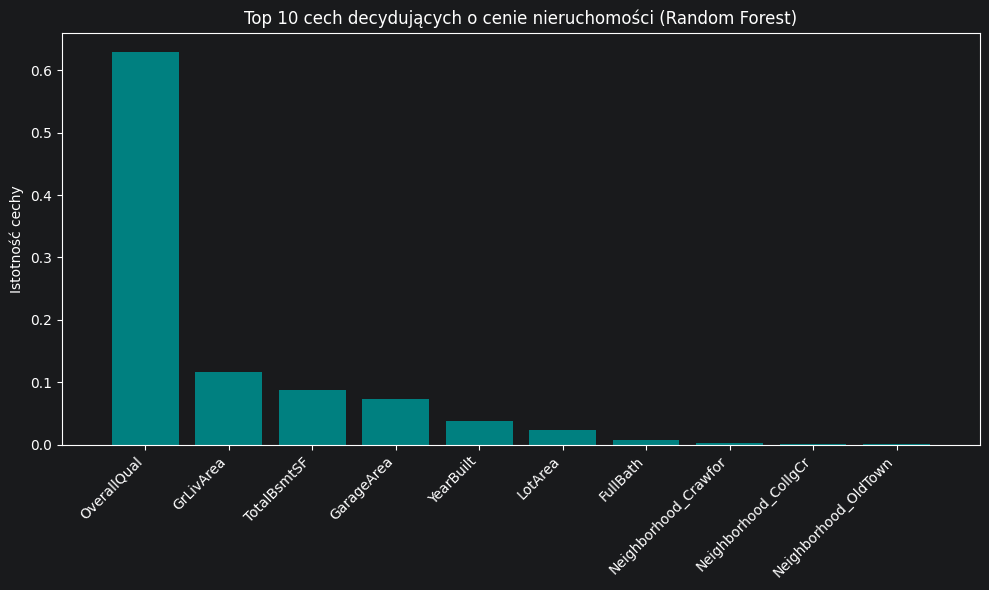

In [28]:
plt.figure(figsize=(10, 6))
plt.title("Top 10 cech decydujących o cenie nieruchomości (Random Forest)")
plt.bar(range(10), importances[indices[:10]], align="center", color='teal')
plt.xticks(range(10), feature_names[indices[:10]], rotation=45, ha='right')
plt.xlim([-1, 10])
plt.ylabel("Istotność cechy")
plt.tight_layout()
plt.show()